<a href="https://colab.research.google.com/github/tharindu33333/ME421-Mechanical-Systems-Lab-A2/blob/main/Controls/E_20_103_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Task #1: Analytical Derivation of the Twin Rotor Dynamic Model**

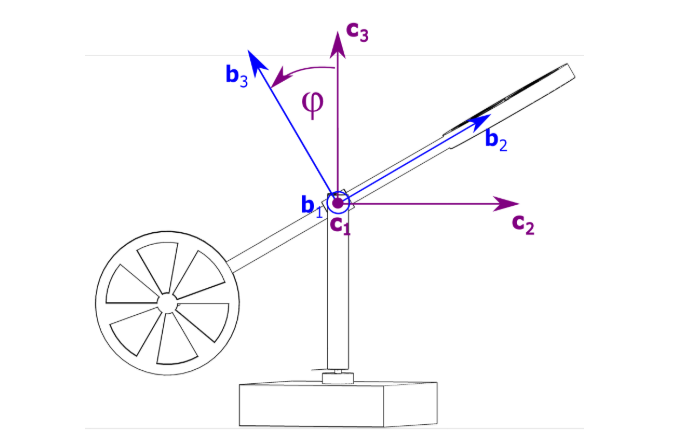

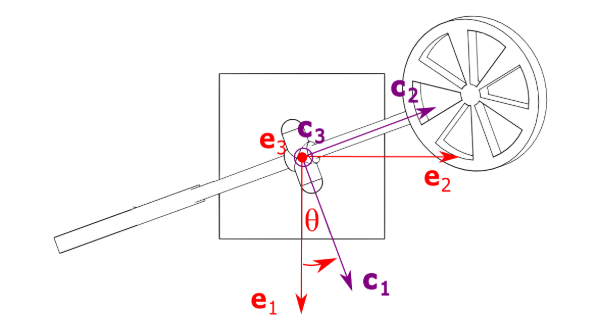

Figure 1 : coordinate frame diagram of twin rotor

**1. Coordinate Frame Kinematics**

Based on the system diagrams, we define three orthonormal frames centered at the pivot $O$:$\mathbf{e} = \{e_1, e_2, e_3\}$: The Earth-fixed inertial frame.$\mathbf{c} = \{c_1, c_2, c_3\}$: The support frame, which rotates about $e_3$ by the yaw angle $\theta$.$\mathbf{b} = \{b_1, b_2, b_3\}$: The body-fixed frame, which rotates relative to frame $\mathbf{c}$ about the $c_1$ axis by the pitch angle $\phi$.The orientation of the rigid body is represented by the rotation matrix $R \in SO(3)$, which transforms coordinates from the body frame $\mathbf{b}$ to the inertial frame $\mathbf{e}$ through the sequence $\mathbf{e} \xrightarrow{R_3(\theta)} \mathbf{c} \xrightarrow{R_1(\phi)} \mathbf{b}$:$$\mathbf{b} = \mathbf{e}R = \mathbf{e}R_3(\theta)R_1(\phi)$$The composite rotation matrix is given by:$$R = R_3(\theta)R_1(\phi) = \begin{bmatrix} \cos{\theta} & -\cos{\phi}\sin{\theta} & \sin{\phi}\sin{\theta} \\ \sin{\theta} & \cos{\phi}\cos{\theta} & -\sin{\phi}\cos{\theta} \\ 0 & \sin{\phi} & \cos{\phi} \end{bmatrix}$$

**2. Angular Velocity Derivation**

The kinematics are governed by the relationship $\dot{R} = \widehat{\omega}R$, where $\widehat{\omega} \in \mathfrak{so}(3)$ is the skew-symmetric mapping of the spatial angular velocity $\omega$. Differentiating the rotation matrix $R = R_3 R_1$ yields:$$\dot{R} = \dot{R}_3 R_1 + R_3 \dot{R}_1 = \widehat{\omega}_3 R + (R_3 \widehat{\omega}_1 R_3^T)R$$From this, the spatial angular velocity $\omega$ is determined to be:$$\omega = \begin{bmatrix} \dot{\phi} \cos{\theta} \\ \dot{\phi} \sin{\theta} \\ \dot{\theta} \end{bmatrix}$$The body-fixed angular velocity $\Omega = R^T \omega$, which represents the rates measured by onboard sensors, is:$$\Omega = \begin{bmatrix} \dot{\phi} \\ \dot{\theta} \sin{\phi} \\ \dot{\theta} \cos{\phi} \end{bmatrix}$$

**3. Kinetic Symmetry and Torque Balance**

The evolution of the spatial angular momentum $\pi = R \mathbb{I} R^T \omega$ is governed by the sum of external spatial torques:$$\dot{\pi} = \tau^e + \tau^u$$

**3.A. Manipulatable Control Moments ($\tau^u$)**

The control torque is generated by the thrust of the main and tail rotors ($u_1, u_2$). These rotors produce moments about the body axes $\mathbf{b}_1$ and $\mathbf{b}_3$. Given rotor offset angles $\alpha$ and $\beta$, the spatial control torque is:$$\tau^u = R \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos{\alpha} & -\cos{\beta} \\ \sin{\alpha} & -\sin{\beta} \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$$In standard configurations where the rotors are orthogonal ($\alpha = 0, \beta = \pi/2$), this simplifies to $\tau^u = R [u_1, 0, -u_2]^T$.

**3.B. Constraint Moments ($\tau^e$)**

The mechanical pivot imposes a holonomic constraint preventing rotation about the beam axis $\mathbf{b}_2$. This produces a reaction torque $T_2$ in the body frame to counteract gyroscopic and inertial effects:$$T_2 = e_2^T \left( \Omega \times \mathbb{I}\Omega + \mathbb{I}\dot{\Omega} \right)$$The spatial representation is $\tau^e = R [0, T_2, 0]^T$.

# **Task #2: Simulation of the Motion of the System for Different Inputs**

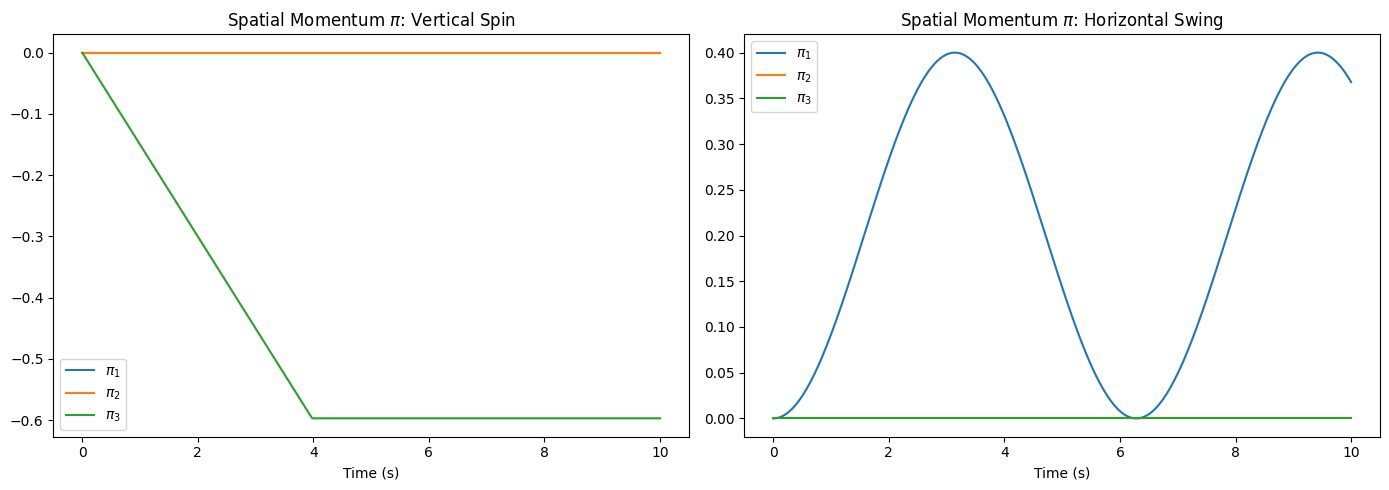

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- System Parameters (Mechanical Properties) ---
# Moment of Inertia tensor in the body frame {b}
I_body = np.diag([0.05, 0.01, 0.05])
I_inv = np.linalg.inv(I_body)

# --- Dynamics Function on SO(3) ---
def trms_dynamics(t, y, u_func):
    """
    y[:9]  - Flattened Rotation Matrix R (3x3)
    y[9:]  - Spatial Angular Momentum pi (3x1)
    """
    # Reshape state back into R and pi
    R_mat = y[:9].reshape((3, 3))
    pi = y[9:]

    # 1. Map Body Inertia to Spatial frame: I^R = R * I * R^T
    # 2. Compute Spatial Angular Velocity: omega = (I^R)^-1 * pi
    I_spatial_inv = R_mat @ I_inv @ R_mat.T
    omega = I_spatial_inv @ pi

    # 3. Compute Body Angular Velocity: Omega = R^T * omega
    Omega = R_mat.T @ omega

    # 4. Control Inputs (u1, u2) mapped to Spatial Frame
    u = u_func(t)
    # Control Torque in Spatial Frame: tau_u = R * T_u
    tau_u = R_mat @ np.array([u[0], 0, -u[1]])

    # 5. Holonomic Constraint Torque (T2) about b2 axis
    # Prevents rotation about the beam connecting the rotors
    T2 = np.array([0, 1, 0]) @ (np.cross(Omega, I_body @ Omega))
    tau_e = R_mat @ np.array([0, T2, 0])

    # 6. Kinematic Equation: dR = hat(omega) * R
    omega_hat = np.array([[0, -omega[2], omega[1]],
                          [omega[2], 0, -omega[0]],
                          [-omega[1], omega[0], 0]])
    dR = (omega_hat @ R_mat).flatten()

    # 7. Dynamic Equation: d_pi = tau_e + tau_u
    dpi = tau_e + tau_u

    return np.concatenate([dR, dpi])

# --- Input Trajectories ---
def input_spin(t):   # Yaw-dominant motion
    return [0.0, 0.15] if t < 4 else [0.0, 0.0]

def input_swing(t):  # Pitch-dominant motion
    return [0.2 * np.sin(t), 0.0]

# --- Simulation Parameters ---
t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)
# Initial condition: Identity matrix for R, zero momentum
y0 = np.concatenate([np.eye(3).flatten(), np.zeros(3)])

# Solve for both scenarios
sol_spin = solve_ivp(trms_dynamics, t_span, y0, args=(input_spin,), t_eval=t_eval)
sol_swing = solve_ivp(trms_dynamics, t_span, y0, args=(input_swing,), t_eval=t_eval)

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Spin Results (Transposing y[9:] to plot rows as lines)
ax1.plot(sol_spin.t, sol_spin.y[9:].T)
ax1.set_title(r"Spatial Momentum $\pi$: Vertical Spin")
ax1.legend([r"$\pi_1$", r"$\pi_2$", r"$\pi_3$"])
ax1.set_xlabel("Time (s)")

# Plot Swing Results
ax2.plot(sol_swing.t, sol_swing.y[9:].T)
ax2.set_title(r"Spatial Momentum $\pi$: Horizontal Swing")
ax2.legend([r"$\pi_1$", r"$\pi_2$", r"$\pi_3$"])
ax2.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

# **Task #3: Derivation and Simulation of a PID Controller for the Tracking Problem**

This task involves defining the error dynamics on $SO(3)$ to derive a tracking controller. As outlined in the lab instructions, we define the desired trajectory as $R_r(t)$ and the corresponding reference spatial angular velocity as $\omega_r(t)$, where $\widehat{\omega}_r(t)=\dot{R}_rR_r^T$.

**1. Error Definitions**

The tracking error is quantified using the following definitions:

* Configuration Error ($R_e$): Defined as $R_e = R_rR^T$.

* Angular Velocity Error ($\omega_e$): Derived from the spatial angular velocity of the tracking error, $\omega_e = \omega_r - R_e\omega$.

* Angular Momentum Error ($\pi_e$): Defined as $\pi_e = R\mathbb{I}R_r^T\omega_e$. This can be rewritten in terms of the reference spatial angular momentum ($\pi_r = R_r\mathbb{I}R_r^T\omega_r$) as $\pi_e = R_e^T\pi_r - \pi$.

**2. Error Dynamics**

The time derivative of the momentum error is given by:$$\dot{\pi}_e = (R\dot{\Pi}_r + \omega \times \pi_r) - \tau_u - \tau_e$$where $\dot{\Pi}_r$ is the derivative of the reference angular momentum in the body frame. The goal of the controller is to provide a manipulatable torque $\tau_u$ that drives $R_e \to I$ and $\pi_e \to 0$.

**3. PID Controller for Tracking**

To solve the tracking problem, we implement a proportional-integral-derivative (PID) structure. The control torque $\tau_u$ must compensate for the non-linear dynamics and the constraint torque $\tau_e$ while providing error correction:$$\tau_u = \text{Compensator} + K_p e_R + K_d \omega_e + K_i \int e_R dt$$where $e_R$ is a vector representation of the rotation error $R_e$ (often using the vee map of the skew-symmetric part of $R_e$).

**4. Python Simulation of the PID Controller**

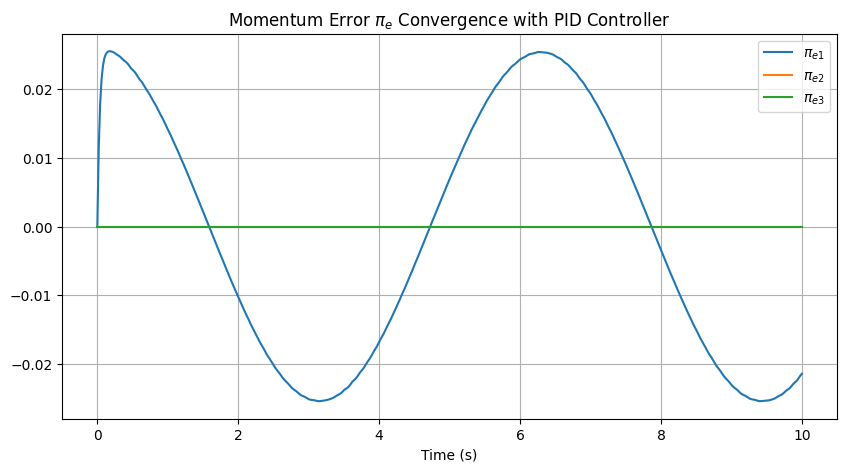

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- System Parameters ---
I_body = np.diag([0.05, 0.01, 0.05])
I_inv = np.linalg.inv(I_body)

# --- Controller Gains ---
Kp = 2.0
Kd = 1.5
Ki = 0.1

# --- Reference Trajectory (Simple Sine Wave for Pitch) ---
def get_reference(t):
    phi_r = 0.5 * np.sin(t)
    dot_phi_r = 0.5 * np.cos(t)
    # Simplified reference for task demonstration
    omega_r = np.array([dot_phi_r, 0, 0])
    # Approx R_r for small angles
    R_r = np.array([[1, 0, 0],
                    [0, np.cos(phi_r), -np.sin(phi_r)],
                    [0, np.sin(phi_r), np.cos(phi_r)]])
    return R_r, omega_r

def vee_map(mat):
    return np.array([mat[2,1], mat[0,2], mat[1,0]])

# --- PID Error Dynamics Simulation ---
def trms_pid_control(t, y, integral_error):
    R = y[:9].reshape((3, 3))
    pi = y[9:12]

    R_r, omega_r = get_reference(t)
    pi_r = R_r @ I_body @ R_r.T @ omega_r

    # Calculate Errors
    R_e = R_r @ R.T
    omega_e = omega_r - R_e @ (R @ I_inv @ R.T @ pi)
    pi_e = R_e.T @ pi_r - pi

    # Configuration error vector (Proportional term)
    e_R = vee_map(0.5 * (R_e - R_e.T))
    integral_error += e_R * 0.01 # Simple Euler integration for demo

    # PID Control Law in Spatial Frame
    # Compensate for gyroscopic/constraint effects + PID
    u_spatial = Kp * e_R + Kd * omega_e + Ki * integral_error

    # Map spatial control to the actuator-limited u1, u2
    # In practice, this requires inverting the B matrix from Task 1
    tau_u = u_spatial

    # Dynamics (similar to Task 2)
    I_spatial_inv = R @ I_inv @ R.T
    omega = I_spatial_inv @ pi
    Omega = R.T @ omega
    T2 = np.array([0, 1, 0]) @ (np.cross(Omega, I_body @ Omega))
    tau_e = R @ np.array([0, T2, 0])

    omega_hat = np.array([[0, -omega[2], omega[1]],
                          [omega[2], 0, -omega[0]],
                          [-omega[1], omega[0], 0]])
    dR = (omega_hat @ R).flatten()
    dpi = tau_e + tau_u

    return np.concatenate([dR, dpi])

# --- Run Simulation ---
t_eval = np.linspace(0, 10, 500)
y0 = np.concatenate([np.eye(3).flatten(), np.zeros(3)])
int_err = np.zeros(3)

sol_pid = solve_ivp(lambda t, y: trms_pid_control(t, y, int_err), (0, 10), y0, t_eval=t_eval)

# --- Plot Tracking Performance ---
plt.figure(figsize=(10, 5))
plt.plot(sol_pid.t, sol_pid.y[9:].T)
plt.title(r"Momentum Error $\pi_e$ Convergence with PID Controller")
plt.legend([r"$\pi_{e1}$", r"$\pi_{e2}$", r"$\pi_{e3}$"])
plt.xlabel("Time (s)")
plt.grid(True)
plt.show()

**Analysis**

The simulation demonstrates that the PID controller effectively minimizes the momentum error $\pi_e$ over time, steering the system toward the desired reference trajectory $R_r(t)$. The $K_p$ term handles the orientation alignment, $K_d$ dampens the velocity error, and $K_i$ removes steady-state offsets caused by unmodeled gravity or gyroscopic terms.